In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples





In [2]:
df = pd.read_csv("bank_data.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [4]:
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(0)

array([[<Axes: title={'center': 'BALANCE'}>,
        <Axes: title={'center': 'BALANCE_FREQUENCY'}>,
        <Axes: title={'center': 'PURCHASES'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES'}>],
       [<Axes: title={'center': 'INSTALLMENTS_PURCHASES'}>,
        <Axes: title={'center': 'CASH_ADVANCE'}>,
        <Axes: title={'center': 'PURCHASES_FREQUENCY'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES_FREQUENCY'}>],
       [<Axes: title={'center': 'PURCHASES_INSTALLMENTS_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_TRX'}>,
        <Axes: title={'center': 'PURCHASES_TRX'}>],
       [<Axes: title={'center': 'CREDIT_LIMIT'}>,
        <Axes: title={'center': 'PAYMENTS'}>,
        <Axes: title={'center': 'MINIMUM_PAYMENTS'}>,
        <Axes: title={'center': 'PRC_FULL_PAYMENT'}>],
       [<Axes: title={'center': 'TENURE'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

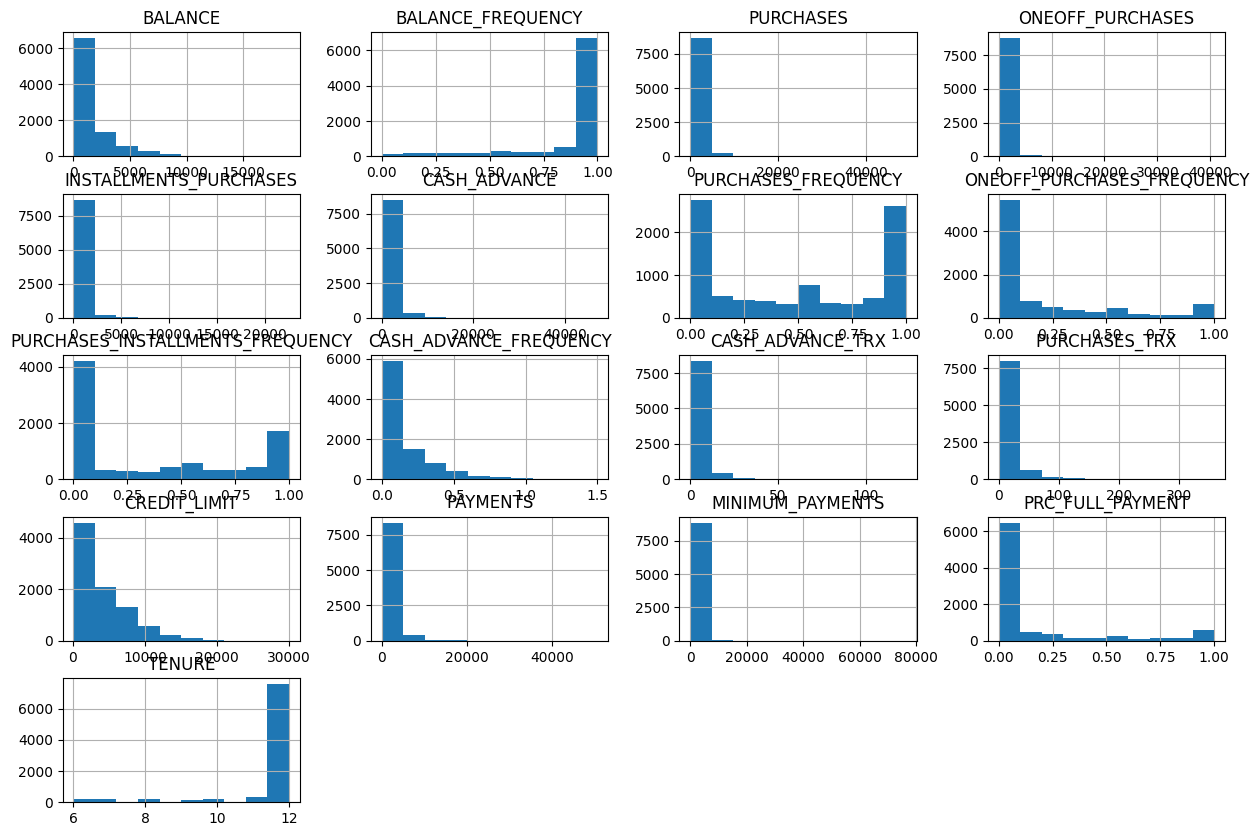

In [ ]:
## Visualiserar för att se spridningen över datan
df.hist(figsize=(15,10))

In [ ]:
## då mycket data var väldigt snett fördelat så behöver vi loga
log_cols = [
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE"
]

for col in log_cols:
    df[col + "_log"] = np.log1p(df[col])

In [ ]:
## Feature engineerar för att skapa variabler som delar upp olika beteenden hos en kund.

# Aktivitet
df["activity"] = (df["PURCHASES_FREQUENCY"] + df["CASH_ADVANCE_FREQUENCY"]) / 2
df["transactions_per_month"] = (df["PURCHASES_TRX"] + df["CASH_ADVANCE_TRX"]) / df["TENURE"]

# Betalbeteende
df["payment_ratio"] = df["PRC_FULL_PAYMENT"] ## payment_ratio visar hur ofta kunden betalar hela skulden.
# Ett högt värde betyder att kunden ofta betalar hela saldot, medan ett lågt värde betyder att kunden oftare lämnar skuld kvar.
df["payment_vs_spend"] = (df["PAYMENTS"] / (df["PURCHASES"] + df["CASH_ADVANCE"] + 1)).clip(0, 5) ## Hur bra kund är på att betala tillbaka

# Risk
df["utilization"] = df["BALANCE"] / (df["CREDIT_LIMIT"] + 1) ## utilization visar hur stor del av kreditgränsen kunden använder. 
# Ett högt värde betyder att kunden använder en stor del av sin tillgängliga kredit, vilket kan indikera högre risk.
df["utilization"] = df["utilization"].clip(0, 1.5)

# Kreditbeteende
df["cash_ratio"] = df["CASH_ADVANCE"] / (df["PURCHASES"] + 100) ## cash_ratio mäter hur mycket kunden använder kontantuttag i relation till vanliga köp.  
#Ett högt värde betyder att kunden använder mer cash advance jämfört med köp.
df["cash_ratio"] = df["cash_ratio"].clip(0, 5)
df["oneoff_ratio"] = df["ONEOFF_PURCHASES"] / (df["PURCHASES"] + 100)
df["installment_ratio"] = df["INSTALLMENTS_PURCHASES"] / (df["PURCHASES"] + 100) ## installment_ratio visar hur stor del av kundens köpbeteende som består av avbetalning. 
## Ett högt värde betyder att kunden använder avbetalning i högre grad.

In [ ]:
## Väljer features inför klustringen
features = [
    "activity",
    "transactions_per_month",

    "payment_ratio",
    "payment_vs_spend", 

    "utilization",

    "cash_ratio",
    "installment_ratio",
    "oneoff_ratio",

    "BALANCE_log",
    "PURCHASES_log",
    "CASH_ADVANCE_log"
]

In [9]:
df[features].isnull().sum()


activity                  0
transactions_per_month    0
payment_ratio             0
payment_vs_spend          0
utilization               1
cash_ratio                0
installment_ratio         0
oneoff_ratio              0
BALANCE_log               0
PURCHASES_log             0
CASH_ADVANCE_log          0
dtype: int64

In [10]:
df[features] = df[features].fillna(0)

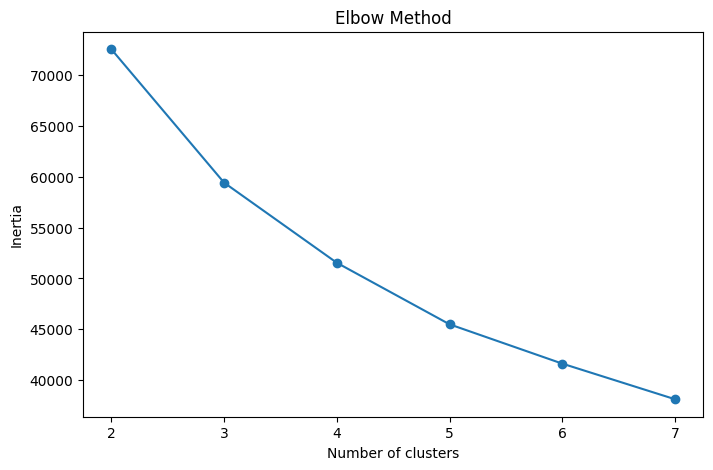

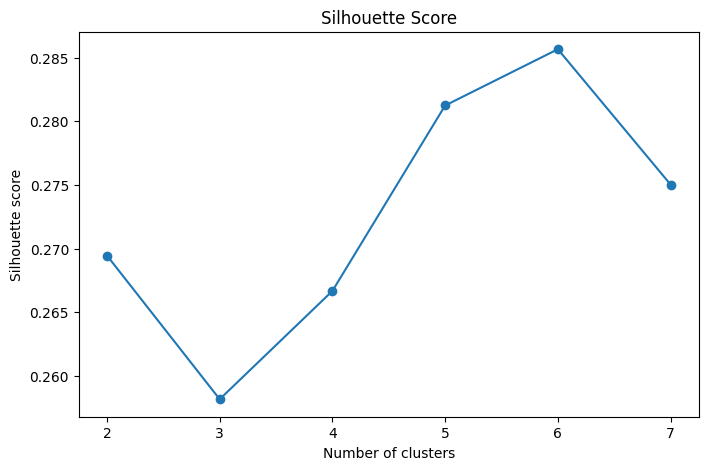

In [11]:
# 1. Skala features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# 2. Testa olika antal kluster med inertia och silhouette
inertia = []
silhouette_scores = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), silhouette_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.show()

# 3. Skapa kluster för k=3 och k=4
for k in [3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df[f"cluster_{k}"] = kmeans.fit_predict(X_scaled)


In [ ]:
## se hur fördelningen blev i grupperna mellan 3 och 4 kluster
df["cluster_3"].value_counts()

cluster_3
1    3265
2    3203
0    2482
Name: count, dtype: int64

In [13]:
df["cluster_4"].value_counts()


cluster_4
2    2370
0    2280
3    2206
1    2094
Name: count, dtype: int64

In [ ]:
## resultatet från kluster
df.groupby("cluster_4")[features].mean()


,activity,transactions_per_month,payment_ratio,payment_vs_spend,utilization,cash_ratio,installment_ratio,oneoff_ratio,BALANCE_log,PURCHASES_log,CASH_ADVANCE_log
cluster_4,,,,,,,,,,,
0,0.385405,1.461666,0.465749,1.210414,0.047765,0.043364,0.631251,0.158406,4.034528,6.251345,0.232480
1,0.202214,0.712175,0.058743,2.055381,0.323226,0.170153,0.113583,0.612457,5.862504,5.882494,1.021301
2,0.151180,0.610352,0.036698,1.327548,0.576630,4.246293,0.019909,0.056092,7.143144,0.699646,6.996949
3,0.516153,3.451009,0.047079,0.820959,0.593996,1.303883,0.459291,0.428603,7.589572,7.081900,4.739072


In [15]:
df.groupby("cluster_3")[features].mean()


,activity,transactions_per_month,payment_ratio,payment_vs_spend,utilization,cash_ratio,installment_ratio,oneoff_ratio,BALANCE_log,PURCHASES_log,CASH_ADVANCE_log
cluster_3,,,,,,,,,,,
0,0.148707,0.596425,0.035239,1.479122,0.585090,4.076015,0.025198,0.061882,7.160548,0.840625,6.775019
1,0.315117,1.139926,0.352573,1.565152,0.060812,0.052246,0.474088,0.275027,4.164463,5.991212,0.299192
2,0.437447,2.710324,0.042813,1.011438,0.565708,0.970340,0.351870,0.521553,7.423415,6.932283,3.719438


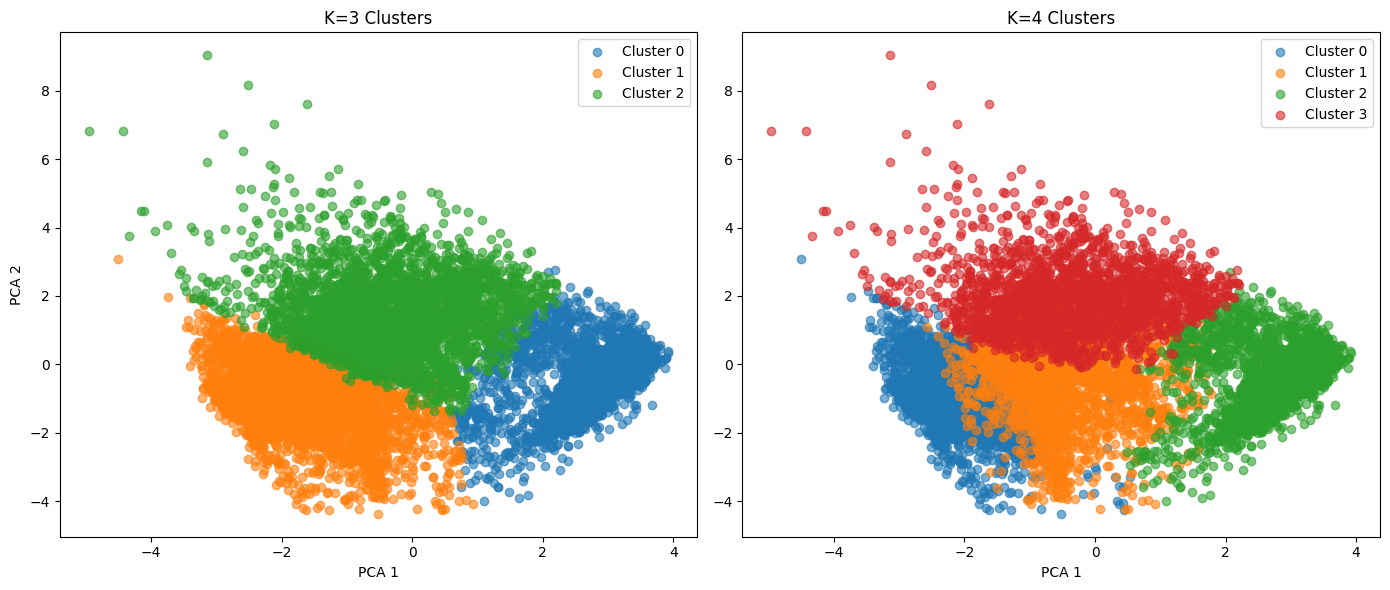

In [ ]:
## Ska visualisera fördelningen av de olika kluster. PCA för att kunna "trycka" in flera variabler i x och y. 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14,6))

for cluster in sorted(df["cluster_3"].unique()):
    subset = df[df["cluster_3"] == cluster]
    
    axes[0].scatter(
        subset["pca1"],
        subset["pca2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

axes[0].set_title("K=3 Clusters")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
axes[0].legend()


for cluster in sorted(df["cluster_4"].unique()):
    subset = df[df["cluster_4"] == cluster]
    
    axes[1].scatter(
        subset["pca1"],
        subset["pca2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

axes[1].set_title("K=4 Clusters")
axes[1].set_xlabel("PCA 1")
axes[1].legend()


plt.tight_layout()
plt.show()

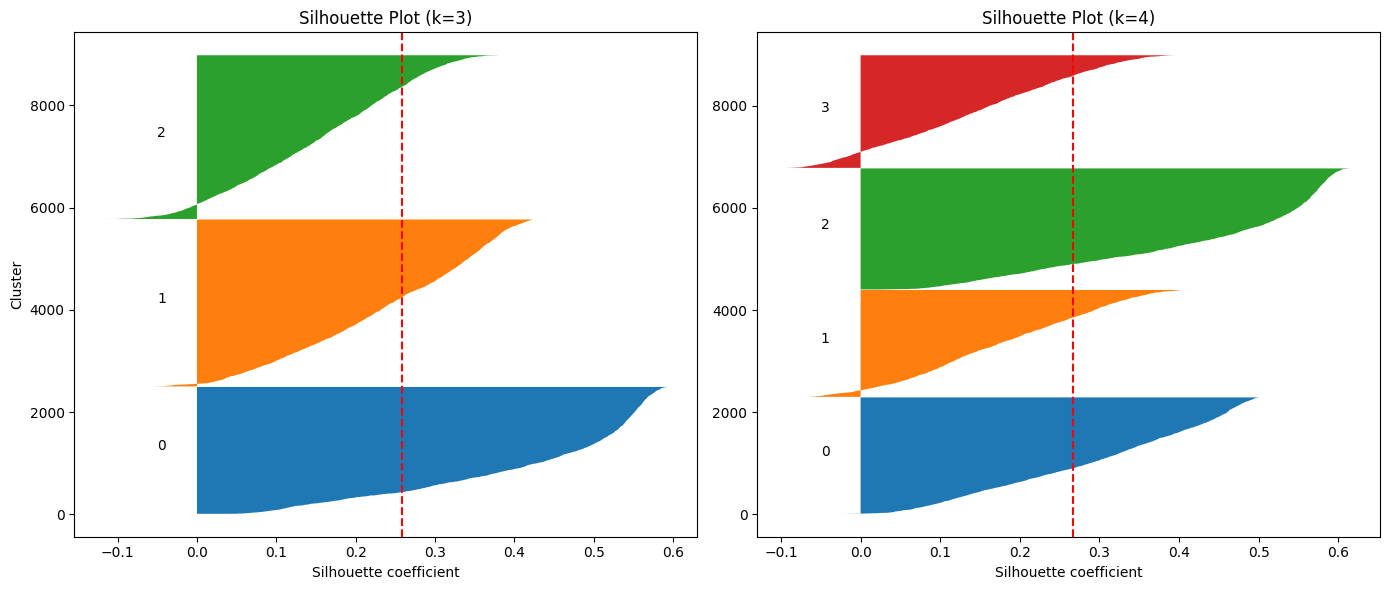

In [ ]:
## Silhouette diagram 
fig, axes = plt.subplots(1, 2, figsize=(14,6))

for idx, (k, cluster_col) in enumerate([(3, "cluster_3"), (4, "cluster_4")]):
    
    cluster_labels = df[cluster_col]
    silhouette_vals = silhouette_samples(X_scaled, cluster_labels)
    avg_score = silhouette_score(X_scaled, cluster_labels)
    
    y_lower = 10
    ax = axes[idx]
    
    for i in np.unique(cluster_labels):
        cluster_silhouette = silhouette_vals[cluster_labels == i]
        cluster_silhouette.sort()
        
        size = cluster_silhouette.shape[0]
        y_upper = y_lower + size
        
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_silhouette
        )
        
        ax.text(-0.05, y_lower + 0.5 * size, str(i))
        y_lower = y_upper + 10
    
    ax.axvline(x=avg_score, color="red", linestyle="--")
    ax.set_title(f"Silhouette Plot (k={k})")
    ax.set_xlabel("Silhouette coefficient")

axes[0].set_ylabel("Cluster")

plt.tight_layout()
plt.show()

In [51]:
## Lönsamhet potential kolumn skapas. 
#  Antar att köp ger viss intäkt, till exempel transaktionsavgifter.
## Antar att kunder med saldo kan generera ränteintäkter.
## Antar att kontantuttag kan ge högre intäkt genom avgifter eller ränta.

df["profitability_score"] = (
    df["PURCHASES"] * 0.01 +
    df["BALANCE"] * 0.05 * (1 - df["PRC_FULL_PAYMENT"]) +
    df["CASH_ADVANCE"] * 0.08
) / (df["TENURE"] + 1)
df["profitability_category"] = pd.qcut(
    df["profitability_score"],
    q=3,
    labels=["Låg lönsamhet", "Medel lönsamhet", "Hög lönsamhet"]
)

In [52]:
df.groupby("cluster_3")["profitability_score"].sum()

cluster_3
0    55695.043672
1     4510.176882
2    59487.756776
Name: profitability_score, dtype: float64

In [ ]:
#Namnge våra kluster
cluster_names = {
    0: "Becknare",
    1: "Mönstermedborgare",
    2: "Stureplan"
}

df["segment"] = df["cluster_3"].map(cluster_names)

In [ ]:
## Se fördelningen av lönsamhet i de olika kluster.
pd.crosstab(
    df["segment"],
    df["profitability_category"],
    normalize="index"
) * 100

profitability_category,Låg lönsamhet,Medel lönsamhet,Hög lönsamhet
segment,,,
Becknare,3.908139,36.220790,59.871072
Mönstermedborgare,85.359877,14.058193,0.581930
Stureplan,3.122073,50.733687,46.144240


In [ ]:
df = df.drop(columns=["cluster_4"]) 
## Vi har valt att gå med kluster 3 även fast sillhouette score visar att kluster 4 är LITE bättre så väljer vi 3 
## pga PCA visualiseringen tyder på 3 distinkta grupper medan 4 överlappar mer med varandra.
# Samt att resultatet från 3 visar tydligare och mer distinkta beteenden mellan grupperna.


In [23]:
pd.set_option('display.max_columns', None)
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,BALANCE_log,PURCHASES_log,CASH_ADVANCE_log,activity,transactions_per_month,payment_ratio,payment_vs_spend,utilization,cash_ratio,oneoff_ratio,installment_ratio,cluster_3,pca1,pca2,profitability_score,profitability_category,segment
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3.735304,4.568506,0.000000,0.083334,0.166667,0.000000,2.093383,0.040860,0.000000,0.000000,0.488229,1,-0.737683,-2.227195,0.230695,Låg lönsamhet,Mönstermedborgare
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,8.071989,0.000000,8.770896,0.125000,0.333333,0.222222,0.636727,0.457430,5.000000,0.000000,0.000000,0,3.071991,-0.323871,49.228929,Hög lönsamhet,Becknare
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,7.822504,6.651791,0.000000,0.500000,1.000000,0.000000,0.803527,0.332642,0.000000,0.885475,0.000000,2,-0.784701,1.105684,10.191473,Medel lönsamhet,Stureplan
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,0.000000,0.000000,12,7.419183,7.313220,5.331694,0.083333,0.166667,0.000000,0.000000,0.222193,0.128698,0.937461,0.000000,2,0.197431,0.455749,8.829736,Medel lönsamhet,Stureplan
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,6.707735,2.833213,0.000000,0.041667,0.083333,0.000000,5.000000,0.680861,0.000000,0.137931,0.000000,0,0.978362,-2.046530,3.157363,Medel lönsamhet,Becknare


In [26]:
df.to_csv("bank_data_with_clusters.csv", index=False)